# Parte 2:

## Análisis de Delitos en EE.UU (1970) mediante Escalamiento Multidimensional

### Contexto
Se analiza una base de datos de actos delictivos en EE.UU. del año 1970. La tabla `crimes.dat` contiene correlaciones entre la ocurrencia de 7 clases de delitos.

### Definición de Distancia
Para cada par de delitos (clases), se define la distancia como:

$$
d(x_i, x_j) = 1 - \rho_{ij}
$$

### Objetivo
Aplicar **escalamiento multidimensional (MDS)** para visualizar las observaciones en un espacio de menor dimensión e interpretar el primer eje principal.

### Importar y visualizar los datos

In [11]:
import pandas as pd

# Importar el archivo crimes.dat. Ajusta el parámetro sep si es necesario (aquí se asume que es CSV separado por comas)
df = pd.read_csv("datasets/crimes.dat", sep=",", skipinitialspace=True)

# Visualizamos el DataFrame importado
print("Datos importados:")
print(df.head())

# Configuramos la columna 'Crime' como índice para trabajar cómodamente
df.set_index("Crime", inplace=True)
print("\nDataFrame con índice 'Crime':")
print(df)


Datos importados:
      Crime  No.     1     2     3     4     5     6     7
0    Murder    1  1.00  0.52  0.34  0.81  0.28  0.06  0.11
1      Rape    2  0.52  1.00  0.55  0.70  0.68  0.60  0.44
2   Robbery    3  0.34  0.55  1.00  0.56  0.62  0.44  0.62
3   Assault    4  0.81  0.70  0.56  1.00  0.52  0.32  0.33
4  Burglary    5  0.28  0.68  0.62  0.52  1.00  0.80  0.70

DataFrame con índice 'Crime':
            No.     1     2     3     4     5     6     7
Crime                                                    
Murder        1  1.00  0.52  0.34  0.81  0.28  0.06  0.11
Rape          2  0.52  1.00  0.55  0.70  0.68  0.60  0.44
Robbery       3  0.34  0.55  1.00  0.56  0.62  0.44  0.62
Assault       4  0.81  0.70  0.56  1.00  0.52  0.32  0.33
Burglary      5  0.28  0.68  0.62  0.52  1.00  0.80  0.70
Larceny       6  0.06  0.60  0.44  0.32  0.80  1.00  0.55
Auto theft    7  0.11  0.44  0.62  0.33  0.70  0.55  1.00


### Preparación de la matriz de correlaciones

In [12]:
# La tabla incluye una columna "No.", que no es necesaria para el análisis de correlación. La eliminamos.
correlation_matrix = df.drop(columns=["No."]).astype(float)
print("\nMatriz de correlaciones:")
print(correlation_matrix)



Matriz de correlaciones:
               1     2     3     4     5     6     7
Crime                                               
Murder      1.00  0.52  0.34  0.81  0.28  0.06  0.11
Rape        0.52  1.00  0.55  0.70  0.68  0.60  0.44
Robbery     0.34  0.55  1.00  0.56  0.62  0.44  0.62
Assault     0.81  0.70  0.56  1.00  0.52  0.32  0.33
Burglary    0.28  0.68  0.62  0.52  1.00  0.80  0.70
Larceny     0.06  0.60  0.44  0.32  0.80  1.00  0.55
Auto theft  0.11  0.44  0.62  0.33  0.70  0.55  1.00


### Cálculo de la matriz de distancias

In [13]:
# Definimos la distancia entre dos variables como: distancia = 1 - correlación
distance_matrix = 1 - correlation_matrix
print("\nMatriz de distancias:")
print(distance_matrix)


Matriz de distancias:
               1     2     3     4     5     6     7
Crime                                               
Murder      0.00  0.48  0.66  0.19  0.72  0.94  0.89
Rape        0.48  0.00  0.45  0.30  0.32  0.40  0.56
Robbery     0.66  0.45  0.00  0.44  0.38  0.56  0.38
Assault     0.19  0.30  0.44  0.00  0.48  0.68  0.67
Burglary    0.72  0.32  0.38  0.48  0.00  0.20  0.30
Larceny     0.94  0.40  0.56  0.68  0.20  0.00  0.45
Auto theft  0.89  0.56  0.38  0.67  0.30  0.45  0.00


### Aplicación de MDS


Coordenadas MDS:
                Dim1      Dim2
Crime                         
Murder      0.209602  0.490927
Rape       -0.102982  0.131432
Robbery     0.238000 -0.145618
Assault     0.125229  0.283502
Burglary   -0.145242 -0.151237
Larceny    -0.350925 -0.203749
Auto theft  0.026318 -0.405257


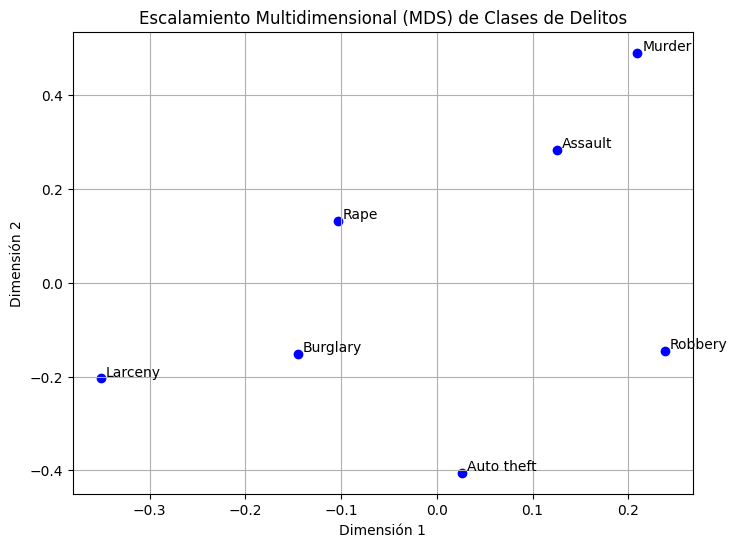

In [14]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# Configuramos y aplicamos el MDS utilizando la matriz de distancias
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
mds_results = mds.fit_transform(distance_matrix)

# Creamos un DataFrame con las coordenadas obtenidas
mds_df = pd.DataFrame(mds_results, columns=["Dim1", "Dim2"], index=correlation_matrix.index)
print("\nCoordenadas MDS:")
print(mds_df)

# Visualización de los resultados
plt.figure(figsize=(8, 6))
plt.scatter(mds_df["Dim1"], mds_df["Dim2"], color="blue")
for crime in mds_df.index:
    plt.text(mds_df.loc[crime, "Dim1"] + 0.005, mds_df.loc[crime, "Dim2"] + 0.005, crime)
plt.title("Escalamiento Multidimensional (MDS) de Clases de Delitos")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(True)
plt.show()


### Interpretación del Primer Eje Principal con PCA


Cargas PCA:
                 PC1       PC2
Crime                         
Murder      0.591595  0.073182
Rape        0.038288  0.516457
Robbery    -0.117235 -0.414929
Assault     0.379742  0.146707
Burglary   -0.328993  0.269361
Larceny    -0.457468  0.543325
Auto theft -0.416039 -0.408009


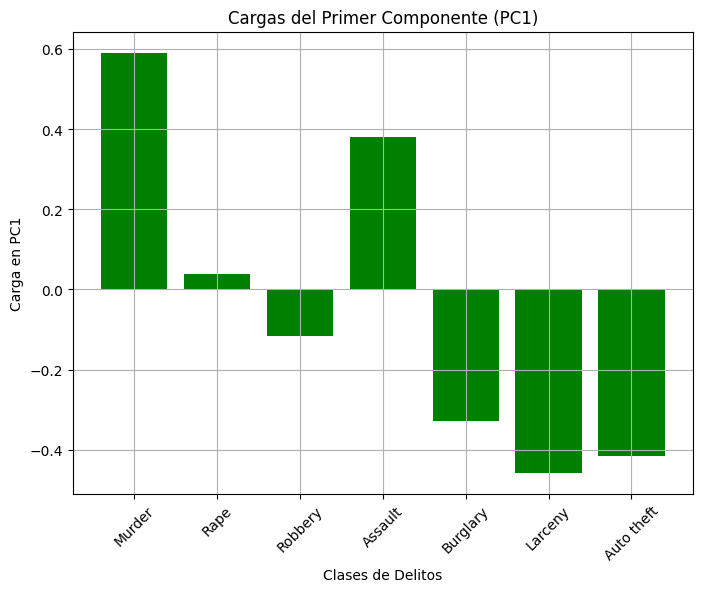

In [15]:
from sklearn.decomposition import PCA

# Aplicamos PCA sobre la matriz de correlación para interpretar el primer eje principal.
pca = PCA(n_components=2)
pca_results = pca.fit_transform(correlation_matrix)

# Creamos un DataFrame para visualizar las cargas de cada variable en los componentes
pca_df = pd.DataFrame(pca.components_.T, index=correlation_matrix.index, columns=["PC1", "PC2"])
print("\nCargas PCA:")
print(pca_df)

# Visualizamos las cargas del primer componente
plt.figure(figsize=(8, 6))
plt.bar(pca_df.index, pca_df["PC1"], color="green")
plt.title("Cargas del Primer Componente (PC1)")
plt.xlabel("Clases de Delitos")
plt.ylabel("Carga en PC1")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
